# Superstore Profitability Analysis
The Superstore dataset contains 9,994 transactions across furniture, office supplies, and technology categories. At an initial glance, highest revenue products might seem the most profitable and hence the most valuable to the business. But high sales can mask thin or even negative profit margins. This analysis investigates where the store is generating revenue without generating profit, what is driving that disconnect, and whether the pattern holds across customer segments and shipping methods.

## Primary Question

**Are the Superstore's highest-revenue products actually its most profitable?**

### Secondary Questions
Q1) What trends do the top-revenue products in each category show with respect to profitability?  
Q2) How does the revenue-profitability relationship vary across customer segments?  
Q3) How has discounting affected the profitability of products?  
Q4) Does shipping method have an effect on the sales vs profitability relationship?

## Data Overview

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

superstore = pd.read_csv('data/superstore.csv', encoding='latin1')
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 1000)

print(f"Rows: {superstore.shape[0]}, Columns: {superstore.shape[1]}")
superstore.head()

Rows: 9994, Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Cleaning

In [34]:
superstore['Order Date'] = pd.to_datetime(superstore['Order Date'])
superstore['Ship Date'] = pd.to_datetime(superstore['Ship Date'])

print(f"Unique orders: {superstore['Order ID'].nunique()}")
print(f"Date range: {superstore['Order Date'].min().date()} to {superstore['Order Date'].max().date()}")
print(f"Customer segments: {list(superstore['Segment'].unique())}")
print(f"Ship modes: {list(superstore['Ship Mode'].unique())}")
print(f"\nMissing values:\n{superstore.isnull().sum()[superstore.isnull().sum() > 0]}")
if superstore.isnull().sum().sum() == 0:
    print("No missing values found.")
print(f"\nNumerical summary:")
superstore[['Sales', 'Profit', 'Discount']].describe().round(2)

Unique orders: 5009
Date range: 2014-01-03 to 2017-12-30
Customer segments: ['Consumer', 'Corporate', 'Home Office']
Ship modes: ['Second Class', 'Standard Class', 'First Class', 'Same Day']

Missing values:
Series([], dtype: int64)
No missing values found.

Numerical summary:


,Sales,Profit,Discount
count,9994.00,9994.00,9994.00
mean,229.86,28.66,0.16
std,623.25,234.26,0.21
min,0.44,-6599.98,0.00
25%,17.28,1.73,0.00
50%,54.49,8.67,0.20
75%,209.94,29.36,0.20
max,22638.48,8399.98,0.80


Date columns were converted to datetime format. The dataset contains no missing values.

## Sales and Profit Distribution

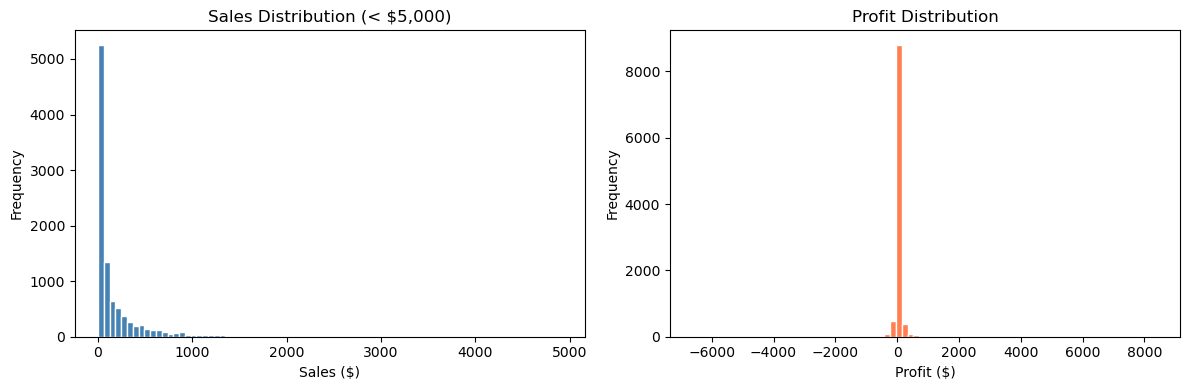

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(superstore[superstore['Sales'] < 5000]['Sales'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution (< $5,000)')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(superstore['Profit'], bins=80, color='coral', edgecolor='white')
axes[1].set_title('Profit Distribution')
axes[1].set_xlabel('Profit ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Sales is right skewed — most transactions are small, with a few high-value orders. Profit is centred around zero with both positive and negative values, which indicates there is a notable share of loss-making transactions.

## Q1) What trends do the top-revenue products in each category show with respect to profitability?

To understand whether the highest-revenue sub-categories are also the most profitable, we rank each sub-category by total sales and by profit margin, then compare the two ranks. If points lie on the diagonal, sales and profit are in concurrence and the deviation tells us where the disconnect lies

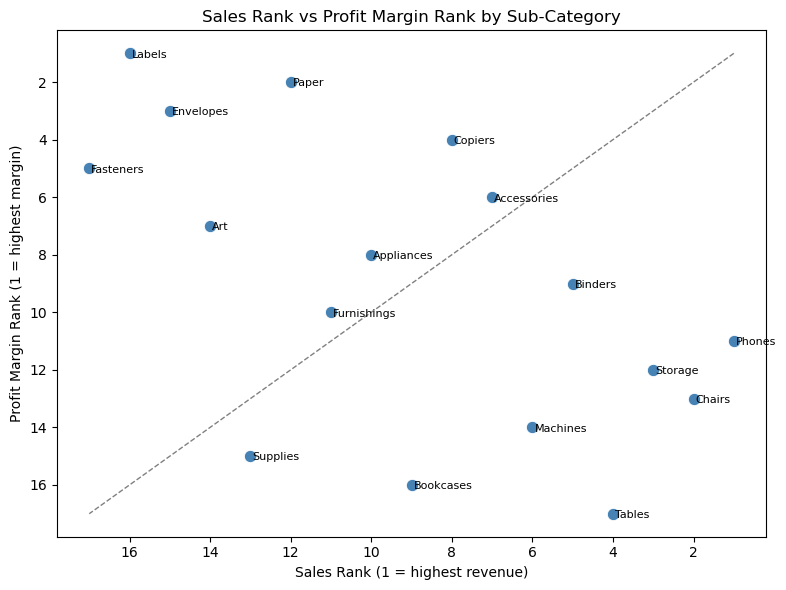

In [36]:
subcat = (
    superstore
    .groupby('Sub-Category')
    .agg({'Sales': 'sum', 'Profit': 'sum'})
    .reset_index()
)

subcat['profit_margin'] = subcat['Profit'] / subcat['Sales']
subcat['sales_rank'] = subcat['Sales'].rank(ascending=False, method='dense').astype(int)
subcat['margin_rank'] = subcat['profit_margin'].rank(ascending=False, method='dense').astype(int)
subcat = subcat.sort_values('sales_rank')

plt.figure(figsize=(8, 6))
sns.scatterplot(data=subcat, x='sales_rank', y='margin_rank', s=80, color='steelblue')
max_rank = max(subcat['sales_rank'].max(), subcat['margin_rank'].max())

plt.plot(
    [1, max_rank],
    [1, max_rank],
    linestyle='--',
    color='gray',
    linewidth=1
)
for _, row in subcat.iterrows():
    plt.text(row['sales_rank'] - 0.05, row['margin_rank'] + 0.15, 
             row['Sub-Category'], fontsize=8)

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel('Sales Rank (1 = highest revenue)')
plt.ylabel('Profit Margin Rank (1 = highest margin)')
plt.title('Sales Rank vs Profit Margin Rank by Sub-Category')
plt.tight_layout()
plt.show()

The data shows clear evidence that products bringing in the largest revenue are not necessarily the most profitable. Phones, Storage, Tables, and Chairs rank among the top revenue generators but are heavily destroying margins. Tables generate `$207K` in revenue but lose `$17.7K` — a -8.6% margin.

Conversely, products producing the lowest sales — Labels, Fasteners, Envelopes, and Paper — are among the highest in profit margins.

## Q2) How does the revenue-profitability relationship vary across customer segments?

To check whether the revenue-margin disconnect is driven by a specific customer segment, we repeat the rank comparison within each segment separately.

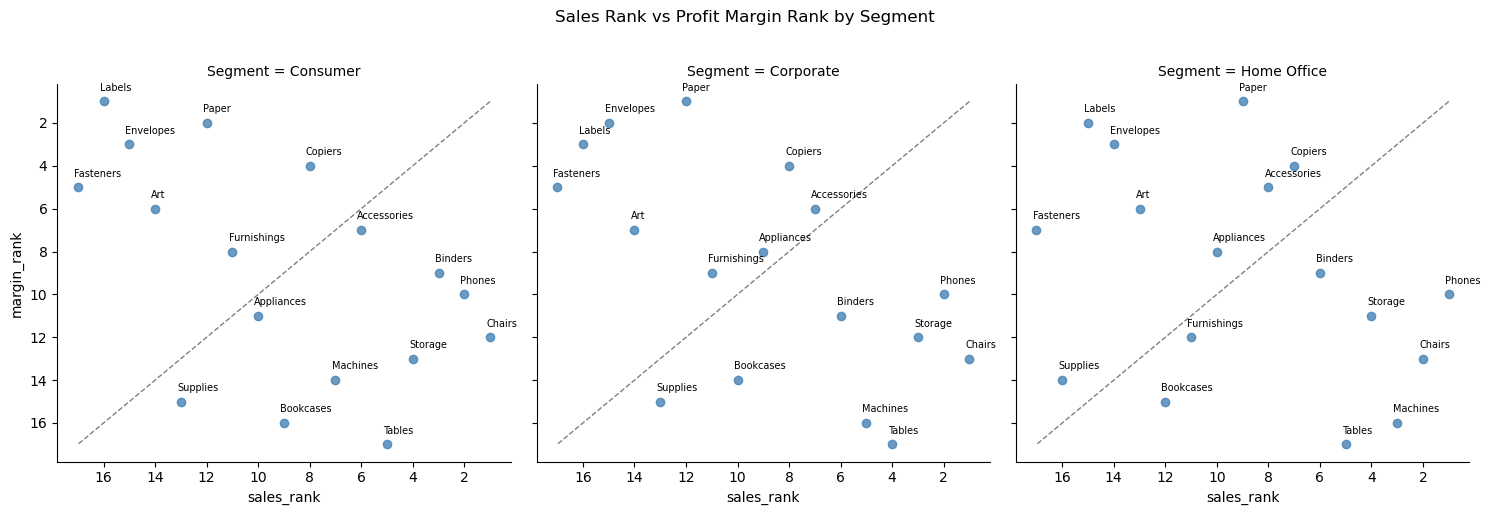

In [37]:
subcat = (
    superstore
    .groupby(['Segment', 'Sub-Category'])
    .agg({'Sales': 'sum', 'Profit': 'sum'})
    .reset_index()
)

subcat['profit_margin'] = subcat['Profit'] / subcat['Sales']
subcat['sales_rank'] = subcat.groupby('Segment')['Sales'].rank(ascending=False, method='dense')
subcat['margin_rank'] = subcat.groupby('Segment')['profit_margin'].rank(ascending=False, method='dense')
subcat = subcat.sort_values(['Segment', 'sales_rank'])

g = sns.lmplot(
    data=subcat, x='sales_rank', y='margin_rank',
    col='Segment', height=5, aspect=1,
    scatter_kws={'color': 'steelblue'},
    fit_reg = False
)

for ax in g.axes.flat:
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.plot([1,17], [1,17], linestyle='--', linewidth=1, color='gray')

for (segment, df_sub), ax in zip(subcat.groupby('Segment'), g.axes.flat):
    for _, row in df_sub.iterrows():
        ax.text(row['sales_rank'] + 0.15, row['margin_rank'] - 0.5,
                row['Sub-Category'], fontsize=7)

plt.suptitle('Sales Rank vs Profit Margin Rank by Segment', y=1.02)
plt.tight_layout()
plt.show()

The revenue-profitability disconnect is not segment-specific — the pattern remains nearly identical across Consumer, Corporate, and Home Office segments. High-revenue sub-categories like Tables and Machines consistently show weak profit margins regardless of who is buying them. 

## Q3) How has discounting affected the profitability of products?

Discounts were categorised into three buckets — No Discount (0%), Moderate (1–20%), and Heavy (>20%) — to examine whether the sub-categories with the weakest margins are also the most heavily discounted.

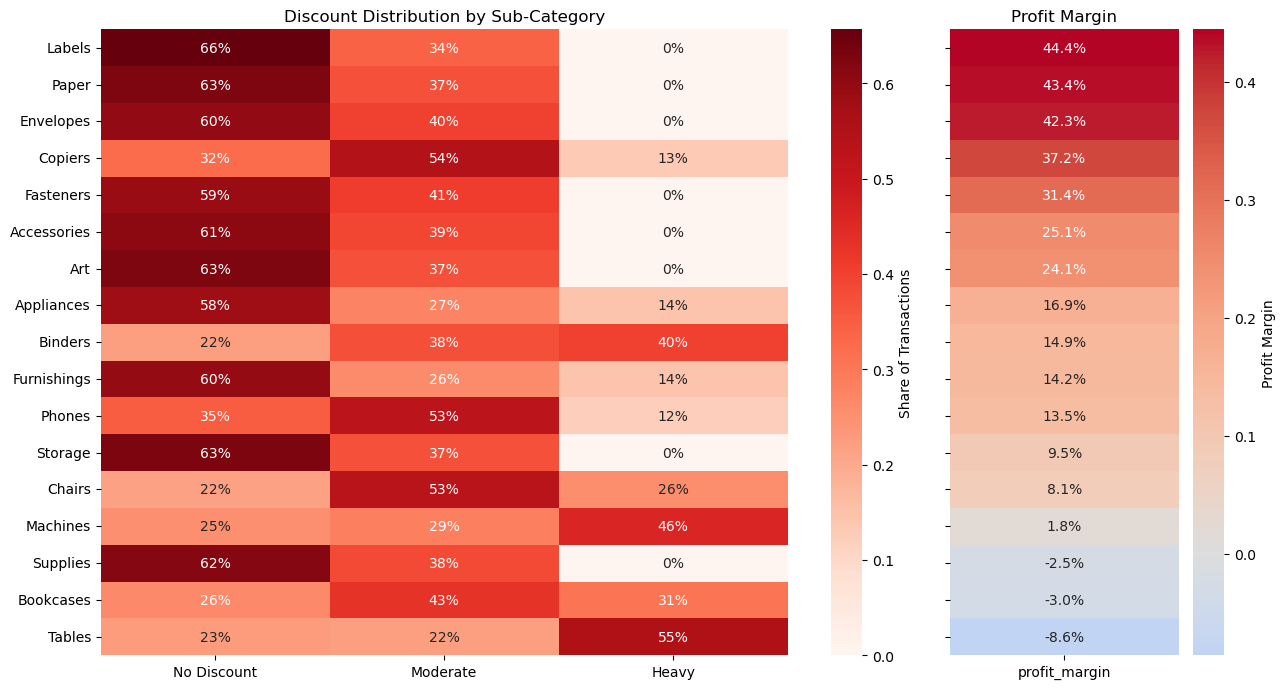

In [48]:
superstore['discount_category'] = pd.cut(
    superstore['Discount'],
    bins=[-0.01, 0, 0.2, 1],
    labels=['No Discount', 'Moderate', 'Heavy']
)

# Discount distribution per sub-category
discount_share = pd.crosstab(
    superstore['Sub-Category'],
    superstore['discount_category'],
    normalize='index'
).reset_index()

# Profit margins per sub-category
top_products = superstore.groupby('Sub-Category').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
top_products['profit_margin'] = top_products['Profit'] / top_products['Sales']

# Merge
final_table = discount_share.merge(
    top_products[['Sub-Category', 'profit_margin']],
    on='Sub-Category'
).sort_values('profit_margin', ascending=False)

df = final_table.set_index('Sub-Category')

# Side-by-side heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 7), gridspec_kw={'width_ratios': [3, 1]})

sns.heatmap(
    df[['No Discount', 'Moderate', 'Heavy']],
    annot=True, fmt='.0%', cmap='Reds', ax=axes[0],
    cbar_kws={'label': 'Share of Transactions'}
)
axes[0].set_title('Discount Distribution by Sub-Category')
axes[0].set_ylabel('')

sns.heatmap(
    df[['profit_margin']],
    annot=True, fmt='.1%', cmap='coolwarm', center=0, ax=axes[1],
    cbar_kws={'label': 'Profit Margin'}
)
axes[1].set_title('Profit Margin')
axes[1].set_ylabel('')
axes[1].set_yticklabels([])

plt.tight_layout()
plt.show()

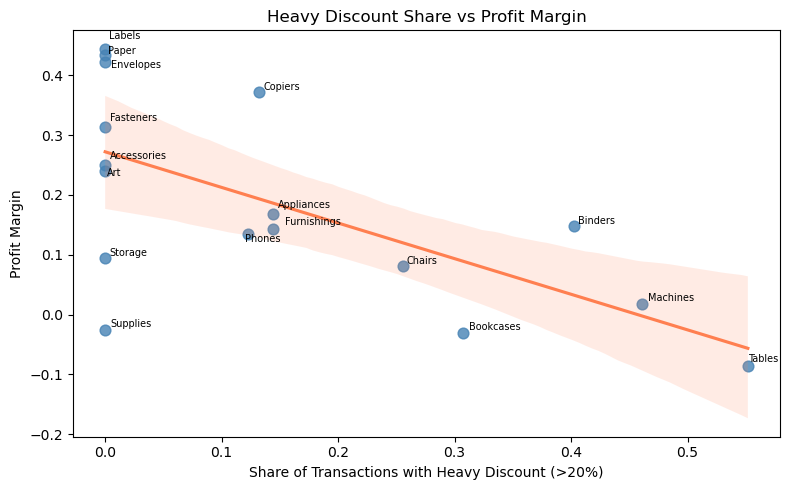

In [39]:
# Scatter: Heavy discount share vs profit margin

from adjustText import adjust_text
plt.figure(figsize=(8, 5))
sns.regplot(data=final_table, x='Heavy', y='profit_margin',
            scatter_kws={'s': 60, 'color': 'steelblue'},
            line_kws={'color': 'coral'})

texts=[]
for _, row in final_table.iterrows():
    texts.append(
        plt.text(
            row['Heavy'],
            row['profit_margin'],
            row['Sub-Category'],
            fontsize=7
        )
    )

adjust_text(texts)

plt.xlabel('Share of Transactions with Heavy Discount (>20%)')
plt.ylabel('Profit Margin')
plt.title('Heavy Discount Share vs Profit Margin')
plt.tight_layout()
plt.show()

Discounting is a major driver of the revenue-margin disconnect. Products with the highest profit margins — Labels (44%), Envelopes (40%), Paper (37%) — have the majority of their sales at zero discount. Products with weak or negative margins — Tables (-9%), Bookcases (-3%), Machines (-4%) — are sold predominantly at moderate and heavy discounts.

The scatter plot confirms a clear negative relationship: as the share of heavily discounted transactions increases, profit margin decreases.

However, discounting is not the sole explanation. Supplies show a negative profit margin despite the majority of products being sold at zero discount. Conversely, Binders and Copiers maintain healthy margins despite significant shares of medium and heavy discounts. These exceptions suggest factors beyond discounting also play a role in revenue-margin relationship.

## Q4) Does shipping method have an effect on the sales vs profitability relationship?

Shipping costs of certain shipping modes could be a reason for high-revenue products producing low margins. We repeat the rank analysis across shipping modes to check.

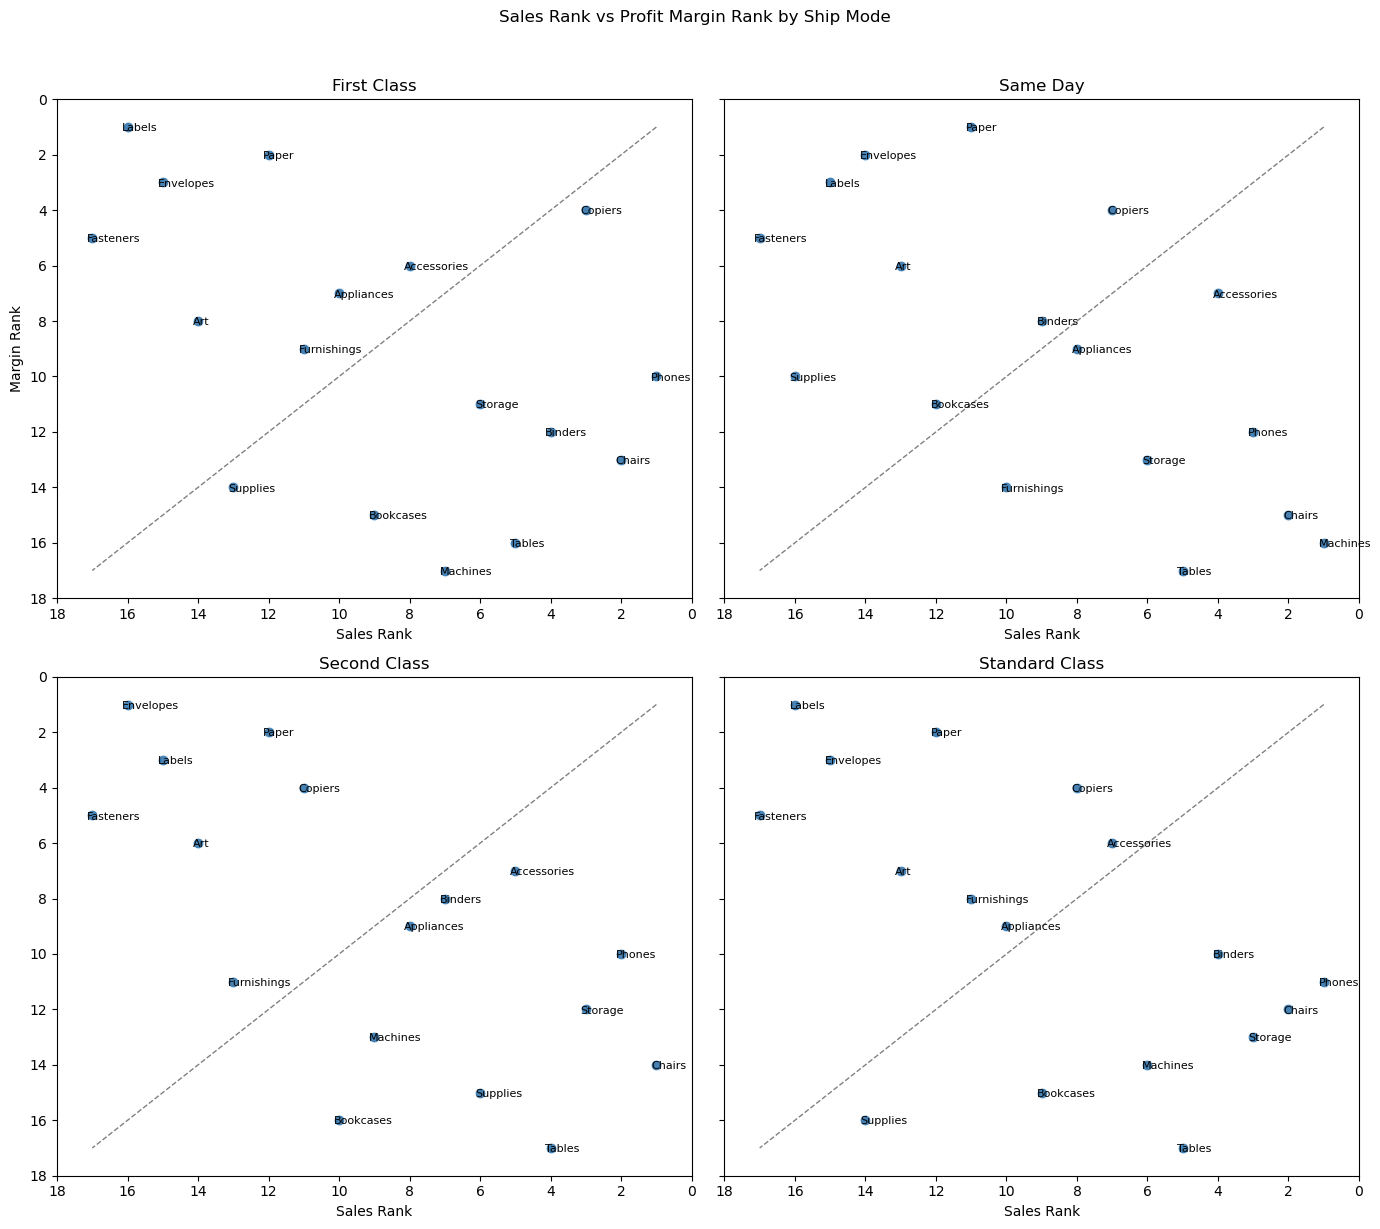

In [40]:
subcat = (
    superstore
    .groupby(['Ship Mode', 'Sub-Category'])
    .agg({'Sales': 'sum', 'Profit': 'sum'})
    .reset_index()
)

subcat['profit_margin'] = subcat['Profit'] / subcat['Sales']
subcat['sales_rank'] = subcat.groupby('Ship Mode')['Sales'].rank(ascending=False, method='dense')
subcat['margin_rank'] = subcat.groupby('Ship Mode')['profit_margin'].rank(ascending=False, method='dense')
subcat = subcat.sort_values(['Ship Mode', 'sales_rank'])

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for ax, (mode, df_sub) in zip(axes, subcat.groupby('Ship Mode')):
    sns.scatterplot(data=df_sub, x='sales_rank', y='margin_rank', 
                    ax=ax, s=60, color='steelblue')
    ax.set_xlim(df_sub['sales_rank'].max() + 1, 0)
    ax.set_ylim(df_sub['margin_rank'].max() + 1, 0)
    ax.plot([1,17], [1,17], linestyle='--', linewidth=1, color='gray')
    ax.set_title(mode)
    ax.set_xlabel('Sales Rank')
    if ax == axes[0]:
        ax.set_ylabel('Margin Rank')
    else:
        ax.set_ylabel('')
    
    for _, row in df_sub.iterrows():
        ax.text(row['sales_rank'] + 0.15, row['margin_rank'] + 0.15,
                row['Sub-Category'], fontsize=8)

plt.suptitle('Sales Rank vs Profit Margin Rank by Ship Mode', y=1.02)
plt.tight_layout()
plt.show()

Shipping method does not appear to drive the revenue-profitability disconnect. The rank patterns are similar across Standard Class, Second Class, First Class, and Same Day shipping — the same sub-categories that underperform on margins (Tables, Machines, Bookcases) do so regardless of how they are shipped.

## SQL Analysis

The dataset was loaded into a SQLite database to demonstrate similar analytical questions can be addressed using SQL. The queries below use CTEs, window functions, CASE WHEN, and GROUP BY with HAVING — constructs commonly used in production analytics environments.

In [41]:
conn = sqlite3.connect('superstore.db')
superstore.to_sql('superstore', conn, if_exists='replace', index=False)
superstore['Order Date'] = pd.to_datetime(superstore['Order Date'])
superstore.to_sql("superstore", conn, if_exists="replace", index=False)

9994

### Revenue & Profit Margin by Sub-Category (CTE + Window Function)
Ranking sub-categories by revenue while flagging those with negative profit margins.

In [42]:
query = """
WITH subcat_metrics AS (
    SELECT  [Sub-Category],
            SUM(Sales) AS total_revenue,
            ROUND(SUM(Profit) * 1.0 / SUM(Sales), 4) AS profit_margin
    FROM superstore
    GROUP BY [Sub-Category]
),
ranked AS (
    SELECT *,
           RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank
    FROM subcat_metrics
)
SELECT * 
FROM ranked
WHERE profit_margin < 0
ORDER BY revenue_rank;
"""
pd.read_sql(query, conn)

,Sub-Category,total_revenue,profit_margin,revenue_rank
0,Tables,206965.5320,-0.0856,4
1,Bookcases,114879.9963,-0.0302,9
2,Supplies,46673.5380,-0.0255,13


Tables, Bookcases and Supplies have negative profit margins. Tables and Bookcases rank in the top 10 products by revenue.

### Top and Bottom 5 Sub-Categories by Profit within Each Region (RANK + PARTITION BY)

In [43]:
query = """
WITH subcat_profit AS (
    SELECT Region, [Sub-Category],
           SUM(Profit) AS total_profit
    FROM superstore
    GROUP BY Region, [Sub-Category]
),
profit_rank AS (
    SELECT *, 
           RANK() OVER (PARTITION BY Region ORDER BY total_profit) AS rank_low,
           RANK() OVER (PARTITION BY Region ORDER BY total_profit DESC) AS rank_high
    FROM subcat_profit
)
SELECT *
FROM profit_rank
WHERE rank_low <= 5 OR rank_high <= 5
ORDER BY Region, total_profit DESC;
"""
pd.read_sql(query, conn)

,Region,Sub-Category,total_profit,rank_low,rank_high
0,Central,Copiers,15608.8413,17,1
1,Central,Phones,12323.0267,16,2
2,Central,Accessories,7251.6306,15,3
3,Central,Paper,6971.9005,14,4
4,Central,Chairs,6592.7221,13,5
5,Central,Machines,-1486.0666,5,13
6,Central,Bookcases,-1997.9043,4,14
7,Central,Appliances,-2638.6175,3,15
8,Central,Tables,-3559.6504,2,16
9,Central,Furnishings,-3906.2168,1,17


The worst-performing sub-categories — Tables, Bookcases, and Machines — are unprofitable in most regions while Furnishings and Appliances show significant losses in specific regions while performing acceptably elsewhere. This points to certain regional factors contributing to losses in specific markets.

### Average Profit by Discount Bucket (CASE WHEN)

In [44]:
query = """
SELECT CASE WHEN Discount = 0 THEN 'No Discount'
            WHEN Discount > 0 AND Discount <= 0.2 THEN 'Moderate (1-20%)'
            ELSE 'Heavy (>20%)'
       END AS discount_bucket,
       ROUND(AVG(Profit), 2) AS avg_profit
FROM superstore
GROUP BY discount_bucket
ORDER BY avg_profit DESC;
"""
pd.read_sql(query, conn)

,discount_bucket,avg_profit
0,No Discount,66.90
1,Moderate (1-20%),26.50
2,Heavy (>20%),-97.18


Average profit per transaction is highest for non-discounted transactions and turns negative for heavily discounted ones — supporting the finding that aggressive discounting is eroding margins. Average profit per transaction is used here to show whether typical orders in these sub-categories are loss-making, complimenting the margin-based analysis above. 

### Yearly Profit Change of Sub-Categories (LAG Window Function)

In [45]:
query = """
WITH yearly_profit AS (
    SELECT
        strftime('%Y', [Order Date]) AS order_year,
        [Sub-Category],
        SUM(Profit) AS yearly_profit
    FROM superstore
    WHERE [Sub-Category] IN (
        'Tables',
        'Bookcases',
        'Machines',
        'Supplies'
    )
    GROUP BY order_year, [Sub-Category]
),

lagged_profit AS (
    SELECT *,
        LAG(yearly_profit) OVER (
            PARTITION BY [Sub-Category]
            ORDER BY order_year
        ) AS prev_year_profit
    FROM yearly_profit
)

SELECT *,
       yearly_profit - prev_year_profit AS profit_change
FROM lagged_profit
ORDER BY [Sub-Category], order_year;
"""
pd.read_sql(query, conn)

,order_year,Sub-Category,yearly_profit,prev_year_profit,profit_change
0,2014,Bookcases,-346.1707,NaN,NaN
1,2015,Bookcases,-2755.2302,-346.1707,-2409.0595
2,2016,Bookcases,212.4710,-2755.2302,2967.7012
3,2017,Bookcases,-583.6261,212.4710,-796.0971
4,2014,Machines,369.1689,NaN,NaN
5,2015,Machines,2977.4856,369.1689,2608.3167
6,2016,Machines,2907.3180,2977.4856,-70.1676
7,2017,Machines,-2869.2156,2907.3180,-5776.5336
8,2014,Supplies,490.0556,NaN,NaN
9,2015,Supplies,-24.8784,490.0556,-514.9340


Only Supplies show consistent negative profit across the years. Machines and Tables saw a huge dip of over `$5000` in profit between 2016 and 2017.

### Sub-Categories with Average Loss by Customer Segment (GROUP BY + HAVING)

In [46]:
query = """
SELECT Segment, [Sub-Category],
       ROUND(AVG(Profit), 2) AS avg_profit
FROM superstore
GROUP BY Segment, [Sub-Category]
HAVING avg_profit < 0
ORDER BY Segment, avg_profit;
"""
pd.read_sql(query, conn)

,Segment,Sub-Category,avg_profit
0,Consumer,Tables,-61.18
1,Consumer,Bookcases,-33.86
2,Consumer,Supplies,-16.58
3,Corporate,Tables,-46.29
4,Home Office,Tables,-57.24


Tables produce average losses across all three customer segments signifying their consistent poor performance.

## Key Findings

1. **High revenue does not equal high profitability.** Several of the store's top-selling sub-categories — Tables, Bookcases, and Machines — carry negative or thin profit margins. Revenue rank and margin rank are poorly correlated across the product catalogue.

2. **The pattern is universal across customer segments.** Consumer, Corporate, and Home Office segments all show the same revenue-margin disconnect, ruling out customer mix as a driver.

3. **Discounting is the primary driver of margin erosion.** Sub-categories with the highest profit margins are overwhelmingly sold at zero discount, while loss-making sub-categories rely heavily on moderate and heavy discounts. There is a clear negative relationship between heavy discount share and profit margin.

4. **Discounting is not the sole explanation.** Supplies show negative margins despite minimal discounting, while Binders and Copiers maintain healthy margins despite significant discounts. Factors beyond discounting, such as pricing, could play a role.

5. **Shipping method does not drive the disconnect.** The same sub-categories underperform on margins regardless of shipping mode.

6. **Recommendation:** The store should review its discounting policy on high-revenue, low-margin sub-categories — particularly Tables and Machines — where heavy discounts are destroying profitability without producing sufficient return. The instances of Supplies, Binders and Copiers suggest that blanket strategy of reducing discounts is not sound and a targeted approach is asked for.

## Limitations

1. Region-wise profitability analysis was not carried out in the Python section, though the SQL queries indicate that the same sub-categories underperform across regions with some region-specific variation.
2. The relationship between order volume and per-unit profitability was not explored.
3. The dataset does not include cost-of-goods data which could have provided indication for products producing low margins without high discounts.